# Regression Models: OLS, Lasso, and Ridge
Using CalEnviroScreen data to see if there is a relationship between hosting capacity and disadvantaged communities.

In [2]:
# import necessary libraries
import geopandas as gpd
import pandas as pd
import os
import matplotlib as plt
import numpy as np

# statistics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

In [3]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [4]:
# read in data
cal = gpd.read_file("../../../../../../capstone/electrigrid/data/dis_adv_comm/calenviroscreen50_D_12226.gdb")
pge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/pge_census_map_new.parquet")
sdge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sdge_census_map_new.parquet")
sce = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet")

## CalEnviroScreen data

In [19]:
cal.head(2)

,tract,ZIP,AppoxLoc,county,region,Population,CIscore,CIscore_Pctl,AirOzone,AirOzone_Pctl,...,PopOver_65,White_Pct,Hispanic_Pct,Black_Pct,NatAmeri_Pct,Asian_Pct,OtherMulti_Pct,Shape_Length,Shape_Area,geometry
0,6.001400e+09,94720,Berkeley,Alameda,Bay Area,3094.0,9.786846,10.388747,0.029251,6.028992,...,29.54,68.10,6.46,4.43,0.00,14.93,6.08,14229.013451,6.945853e+06,"MULTIPOLYGON (((-197333.073 -12225.564, -19731..."
1,6.001400e+09,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,25.51,67.27,9.36,2.05,0.67,12.23,8.41,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839..."


### Keep only certain variables of interest

In [6]:
cal_clean = cal[['tract', 'ZIP', 'Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct']]

## Utility data

In [21]:
# concatenate the three utilities into one
utility = pd.concat([pge, sdge, sce])

In [22]:
utility.head(2)

,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count
0,06085507002,"POLYGON ((-176262.283 -88639.818, -176244.255 ...",0.368304,0.129625,0.371032,0.101275,5.454829,1.503846,5.452101,534.0
1,06085504323,"POLYGON ((-167172.267 -66461.523, -167161.577 ...",3.042006,2.553713,2.494846,1.980096,8.368178,2.124298,8.915339,931.0


### Stats df

Join hosting capacity to census-tract-level sociodemographic variables.

In [7]:
# change tract column in `cal` to object
cal_clean['tract'] = cal_clean['tract'].astype('string')

# strip decimal (.0) at the end) -- ONLY RUN ONCE
cal_clean['tract'] = cal_clean['tract'].str[:-2] 

# add start 0 back in -- ONLY RUN ONCE
cal_clean['tract'] = '0' + cal_clean['tract']

/tmp/ipykernel_236239/2057411967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal_clean['tract'] = cal_clean['tract'].astype('string')
/tmp/ipykernel_236239/2057411967.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal_clean['tract'] = cal_clean['tract'].str[:-2]
/tmp/ipykernel_236239/2057411967.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

In [14]:
stats = pd.merge(cal_clean, utility, left_on = "tract", right_on = "GEOID")

In [50]:
stats.head()

,tract,ZIP,AppoxLoc,county,region,Population,CIscore,CIscore_Pctl,AirOzone,AirOzone_Pctl,...,Shape_Length,Shape_Area,geometry_x,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry_y,avg_DER_total_pv_opflex_hh
0,06001400100,94720,Berkeley,Alameda,Bay Area,3094.0,9.786846,10.388747,0.029251,6.028992,...,14229.013451,6.945853e+06,"MULTIPOLYGON (((-197333.073 -12225.564, -19731...",06001400100,412.0,0.070207,1.711574,NaN,"POLYGON ((-197333.073 -12225.563, -197310.342 ...",NaN
1,06001400200,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839...",06001400200,408.0,NaN,NaN,NaN,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",NaN
2,06001400200,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839...",06001400200,185.0,1.245549,0.533618,1.503659,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",NaN
3,06001400300,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909...",06001400300,1434.0,NaN,NaN,NaN,"POLYGON ((-199103.674 -17489.695, -199097.315 ...",NaN
4,06001400300,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909...",06001400300,994.0,1.571644,0.001033,1.727566,"POLYGON ((-199103.674 -17489.695, -199097.315 ...",NaN


## Basic linear regression

<Axes: ylabel='Frequency'>

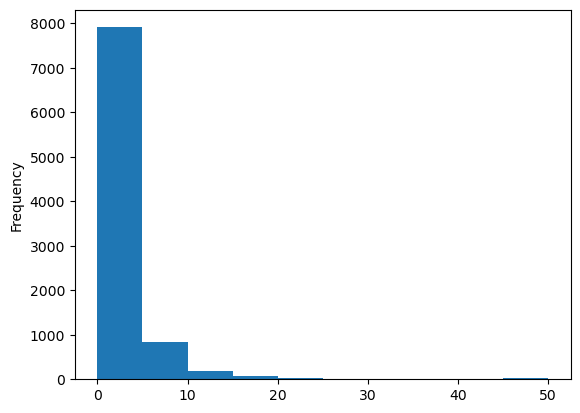

In [15]:
stats['avg_DER_remain_pv_hh'].plot(kind = "hist")

In [27]:
# drop NA values
stats = stats.dropna()

In [28]:
# initialize model
model_lm = LinearRegression()

# predictor variables (retrieved from cal.columns)
X = stats[['Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct']]

y = stats['avg_DER_remain_pv_hh']

# split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42) # need stratify?

# fit the scaler ONLY to X test (don't scale testing data)
scaler = StandardScaler().fit(X_train)

# create scaled versions of training data
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [29]:
# fit model
model_lm.fit(X_train_s, y_train)

# predict y
y_pred = model_lm.predict(X_test_s)

# Calculate MSE and R^2 for Ridge regression
lm_mse = mean_squared_error(y_test, y_pred)

In [30]:
lm_mse

15.546935908357446

### Lasso regression
To find which predictors are actually relevant

In [85]:
# initialize and fit model
lasso_model = Lasso()
lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_test)


# Calculate MSE and R^2 for Lasso regression
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)



print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R²:", lasso_r2)

Lasso Regression MSE: 10.445571896964418
Lasso Regression R²: 0.05334861379250855


In [90]:
# Create and fit Ridge regression model
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

# Generate predictions
ridge_predictions = ridge_model.predict(X_test)

# Calculate MSE and R^2 for Ridge regression
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MSE: 10.17667162060802
Ridge Regression R²: 0.0777182530880206


In [106]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore',
       'CIscore_Pctl', 'AirOzone', 'AirOzone_Pctl', 'AirPM25', 'AirPM25_Pctl',
       'ChildLead', 'ChildLead_Pctl', 'DieselPM', 'DieselPM_Pctl',
       'DrinkingWater', 'DrinkingWater_Pctl', 'Pesticides', 'Pesticides_Pctl',
       'ToxReleases', 'ToxReleases_Pctl', 'TrafficImp', 'TrafficImp_Pctl',
       'CleanupSites', 'CleanupSites_Pctl', 'gwthreats', 'GWThreats_Pctl',
       'HazWaste', 'HazWaste_Pctl', 'ImpWaters', 'ImpWaters_Pctl',
       'SmAirToxSites', 'SmAirToxSites_Pctl', 'SolidWaste', 'SolidWaste_Pctl',
       'Pollution', 'PollutionScore', 'Pollution_Pctl', 'asthma',
       'Asthma_Pctl', 'Cardiovascular', 'Cardiovascular_Pctl', 'DiabetesPrev',
       'DiabetesPrev_Pctl', 'LowBirthWeight', 'LowBirthWeight_Pctl',
       'Education', 'Education_Pctl', 'HousingBurden', 'HousingBurden_Pctl',
       'LinguisticIso', 'LinguisticIso_Pctl', 'Poverty', 'Poverty_Pctl',
       'Unemployment', 'Unemployment_Pctl', 'PopChar', 'PopCharScore',
       'PopChar_Pctl', 'PopUnd_10', 'Pop10_64', 'PopOver_65', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct'],
    
    # OLS coefficients
    'Lasso Coefficient': lasso_model.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
#print(table.to_string(index=False))

In [98]:
# remove all variables where Lasso brought them down to 0
table[table['Lasso Coefficient'] > 0]

,Feature,Lasso Coefficient
4,AirOzone_Pctl,0.068333
10,DieselPM_Pctl,0.011653
12,DrinkingWater_Pctl,0.011297
14,Pesticides_Pctl,0.001036
15,ToxReleases,0.000558
19,CleanupSites,0.088187
24,HazWaste_Pctl,0.018243
28,SmAirToxSites_Pctl,0.018184
30,SolidWaste_Pctl,0.008221
45,HousingBurden_Pctl,0.003692


In [100]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore',
       'CIscore_Pctl', 'AirOzone', 'AirOzone_Pctl', 'AirPM25', 'AirPM25_Pctl',
       'ChildLead', 'ChildLead_Pctl', 'DieselPM', 'DieselPM_Pctl',
       'DrinkingWater', 'DrinkingWater_Pctl', 'Pesticides', 'Pesticides_Pctl',
       'ToxReleases', 'ToxReleases_Pctl', 'TrafficImp', 'TrafficImp_Pctl',
       'CleanupSites', 'CleanupSites_Pctl', 'gwthreats', 'GWThreats_Pctl',
       'HazWaste', 'HazWaste_Pctl', 'ImpWaters', 'ImpWaters_Pctl',
       'SmAirToxSites', 'SmAirToxSites_Pctl', 'SolidWaste', 'SolidWaste_Pctl',
       'Pollution', 'PollutionScore', 'Pollution_Pctl', 'asthma',
       'Asthma_Pctl', 'Cardiovascular', 'Cardiovascular_Pctl', 'DiabetesPrev',
       'DiabetesPrev_Pctl', 'LowBirthWeight', 'LowBirthWeight_Pctl',
       'Education', 'Education_Pctl', 'HousingBurden', 'HousingBurden_Pctl',
       'LinguisticIso', 'LinguisticIso_Pctl', 'Poverty', 'Poverty_Pctl',
       'Unemployment', 'Unemployment_Pctl', 'PopChar', 'PopCharScore',
       'PopChar_Pctl', 'PopUnd_10', 'Pop10_64', 'PopOver_65', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct'],
    
    # OLS coefficients
    'Ridge Coefficient': ridge_model.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

            Feature  Ridge Coefficient
         Population          -0.000351
            CIscore           0.044707
       CIscore_Pctl           0.078705
           AirOzone          -0.000026
      AirOzone_Pctl           0.099085
            AirPM25          -2.813260
       AirPM25_Pctl           0.123666
          ChildLead          -0.681177
     ChildLead_Pctl           0.649318
           DieselPM           0.076320
      DieselPM_Pctl           0.038011
      DrinkingWater          -0.152701
 DrinkingWater_Pctl           0.153384
         Pesticides           0.000113
    Pesticides_Pctl           0.020924
        ToxReleases          -0.000492
   ToxReleases_Pctl           0.083614
         TrafficImp          -0.000258
    TrafficImp_Pctl           0.008323
       CleanupSites           0.189095
  CleanupSites_Pctl          -0.014577
          gwthreats          -0.032989
     GWThreats_Pctl           0.024662
           HazWaste           0.513316
      HazWaste_Pctl      

### Principal Component Analysis

In [104]:
# initialize model
lasso_cv = LassoCV(alphas=lambdas, cv=10)

# fit to training data
lasso_cv.fit(X_train_s, y_train)

# explore best lambda
print(f'The best lambda value for this model is {lasso_cv.alpha_}.')

/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.077e-01, tolerance: 6.432e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.520e+00, tolerance: 6.432e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

The best lambda value for this model is 0.3351602650938841.


/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.238e-01, tolerance: 5.892e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.487e-01, tolerance: 5.892e-01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sc

In [105]:
lasso_cv.coef_

array([-0.17330765,  0.        ,  0.        ,  0.        ,  0.17175923,
       -0.        , -0.        , -0.        , -0.        ,  0.        ,
        0.        ,  0.        ,  0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        ,  0.        ,  0.54614804,
        0.        , -0.        ,  0.        ,  0.        ,  0.06202803,
       -0.        , -0.        ,  0.        ,  0.25983596,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.24531711, -0.        ,
       -0.        , -0.        , -0.        , -0.        ,  0.        ,
        0.        , -0.        , -0.        ,  0.        ,  0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        ,  0.        , -0.        ,  0.        , -0.        ,
        0.        ,  0.        ,  0.        ,  0.        ])

In [107]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore',
       'CIscore_Pctl', 'AirOzone', 'AirOzone_Pctl', 'AirPM25', 'AirPM25_Pctl',
       'ChildLead', 'ChildLead_Pctl', 'DieselPM', 'DieselPM_Pctl',
       'DrinkingWater', 'DrinkingWater_Pctl', 'Pesticides', 'Pesticides_Pctl',
       'ToxReleases', 'ToxReleases_Pctl', 'TrafficImp', 'TrafficImp_Pctl',
       'CleanupSites', 'CleanupSites_Pctl', 'gwthreats', 'GWThreats_Pctl',
       'HazWaste', 'HazWaste_Pctl', 'ImpWaters', 'ImpWaters_Pctl',
       'SmAirToxSites', 'SmAirToxSites_Pctl', 'SolidWaste', 'SolidWaste_Pctl',
       'Pollution', 'PollutionScore', 'Pollution_Pctl', 'asthma',
       'Asthma_Pctl', 'Cardiovascular', 'Cardiovascular_Pctl', 'DiabetesPrev',
       'DiabetesPrev_Pctl', 'LowBirthWeight', 'LowBirthWeight_Pctl',
       'Education', 'Education_Pctl', 'HousingBurden', 'HousingBurden_Pctl',
       'LinguisticIso', 'LinguisticIso_Pctl', 'Poverty', 'Poverty_Pctl',
       'Unemployment', 'Unemployment_Pctl', 'PopChar', 'PopCharScore',
       'PopChar_Pctl', 'PopUnd_10', 'Pop10_64', 'PopOver_65', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct'],
    
    # OLS coefficients
    'Lasso Coefficient': lasso_cv.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
#print(table.to_string(index=False))

In [108]:
table[table['Lasso Coefficient'] > 0 ]

,Feature,Lasso Coefficient
4,AirOzone_Pctl,0.171759
19,CleanupSites,0.546148
24,HazWaste_Pctl,0.062028
28,SmAirToxSites_Pctl,0.259836


In [111]:
# initialize and fit model
lasso_model = Lasso()
lasso_model.fit(X_train_s, y_train)

lasso_cv_pred = lasso_cv.predict(X_test_s)


# Calculate MSE and R^2 for Lasso regression
lasso_cv_mse = mean_squared_error(y_test, lasso_cv_pred)
lasso_cv_r2 = r2_score(y_test, lasso_predictions)

In [112]:
lasso_cv_mse

10.414725965323878

In [114]:
# assign lambda values to loop over
lambdas = np.logspace(-4,4, 100)

# initiate model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')

# fit to training data
ridge_cv.fit(X_train_s, y_train)

# explore best lambda
print(f'The best lambda value for this model is {ridge_cv.alpha_}.')

The best lambda value for this model is 1072.2672220103252.


In [115]:
# predict using the test set
y_test_pred_rcv = ridge_cv.predict(X_test_s)

# compute MSE
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

In [116]:
mse_rcv

9.916828482654491

In [125]:
ridge_cv.score(y_test, y_test_pred_rcv)

ValueError: X has 201 features, but RidgeCV is expecting 64 features as input.

In [123]:
y_test = np.array([y_test])

In [124]:
y_test

array([[1.32519500e+00, 1.29332368e+00, 5.15650233e+00, 5.54213577e-01,
        8.51535282e+00, 6.31318970e+00, 2.39442919e+00, 3.19021072e+00,
        1.45443671e-01, 1.39136632e+00, 3.40148593e-01, 2.64249723e-01,
        3.69148637e+00, 2.92423729e+00, 4.65270614e+00, 3.95023803e+00,
        9.45045314e-01, 3.46280583e+00, 1.79710573e+00, 1.43212435e+00,
        8.48919280e-01, 1.67262925e+00, 1.39016390e+00, 1.38317651e+01,
        6.41245544e-01, 3.85770497e+00, 1.33412047e+00, 2.32354947e+00,
        3.99381179e-01, 2.59686247e-01, 1.21424707e+01, 6.85529917e+00,
        2.86949652e+00, 3.62054544e+00, 2.56314866e+00, 2.54830214e-02,
        4.88738215e+00, 6.11290192e+00, 2.69469044e+00, 1.01490045e+00,
        5.43597558e-03, 1.08880964e+00, 1.45195514e+00, 6.69909282e-01,
        1.54500801e+00, 5.72705966e-01, 5.10966214e+00, 2.02319512e+00,
        1.66951995e+00, 4.29752200e+00, 3.04982737e+00, 2.92581388e+00,
        5.82528005e-01, 1.64673565e-01, 5.03111643e-01, 1.094312

In [126]:
len(y_test)

1

In [127]:
len(y_train)

466

In [130]:
# create table of feature names and their coefficients
table = {
    # feature names
    'Feature': ['Population', 'CIscore',
       'CIscore_Pctl', 'AirOzone', 'AirOzone_Pctl', 'AirPM25', 'AirPM25_Pctl',
       'ChildLead', 'ChildLead_Pctl', 'DieselPM', 'DieselPM_Pctl',
       'DrinkingWater', 'DrinkingWater_Pctl', 'Pesticides', 'Pesticides_Pctl',
       'ToxReleases', 'ToxReleases_Pctl', 'TrafficImp', 'TrafficImp_Pctl',
       'CleanupSites', 'CleanupSites_Pctl', 'gwthreats', 'GWThreats_Pctl',
       'HazWaste', 'HazWaste_Pctl', 'ImpWaters', 'ImpWaters_Pctl',
       'SmAirToxSites', 'SmAirToxSites_Pctl', 'SolidWaste', 'SolidWaste_Pctl',
       'Pollution', 'PollutionScore', 'Pollution_Pctl', 'asthma',
       'Asthma_Pctl', 'Cardiovascular', 'Cardiovascular_Pctl', 'DiabetesPrev',
       'DiabetesPrev_Pctl', 'LowBirthWeight', 'LowBirthWeight_Pctl',
       'Education', 'Education_Pctl', 'HousingBurden', 'HousingBurden_Pctl',
       'LinguisticIso', 'LinguisticIso_Pctl', 'Poverty', 'Poverty_Pctl',
       'Unemployment', 'Unemployment_Pctl', 'PopChar', 'PopCharScore',
       'PopChar_Pctl', 'PopUnd_10', 'Pop10_64', 'PopOver_65', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct'],
    
    # OLS coefficients
    'Lasso Coefficient': ridge_cv.coef_,
}

# convert to dataframe and print, so it appears in a table format
table = pd.DataFrame(table)
print(table.to_string(index=False))

            Feature  Lasso Coefficient
         Population          -0.154382
            CIscore           0.017967
       CIscore_Pctl           0.013803
           AirOzone           0.121372
      AirOzone_Pctl           0.130628
            AirPM25          -0.045579
       AirPM25_Pctl          -0.038827
          ChildLead          -0.005734
     ChildLead_Pctl          -0.003902
           DieselPM           0.002106
      DieselPM_Pctl           0.078986
      DrinkingWater           0.021847
 DrinkingWater_Pctl           0.029800
         Pesticides          -0.018316
    Pesticides_Pctl          -0.051803
        ToxReleases           0.030009
   ToxReleases_Pctl           0.002186
         TrafficImp          -0.049899
    TrafficImp_Pctl          -0.007095
       CleanupSites           0.190264
  CleanupSites_Pctl           0.078800
          gwthreats          -0.007980
     GWThreats_Pctl           0.008396
           HazWaste           0.087775
      HazWaste_Pctl      

In [129]:
table

,Feature,Lasso Coefficient
0,Population,-0.154382
1,CIscore,0.017967
2,CIscore_Pctl,0.013803
3,AirOzone,0.121372
4,AirOzone_Pctl,0.130628
...,...,...
59,Hispanic_Pct,-0.068364
60,Black_Pct,0.016726
61,NatAmeri_Pct,0.026541
62,Asian_Pct,0.095006


### Just race as vars

In [137]:
race = stats[['Poverty',
       'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct', 'avg_DER_remain_pv_hh']]

In [138]:
race

,Poverty,Unemployment,White_Pct,Hispanic_Pct,Black_Pct,NatAmeri_Pct,Asian_Pct,OtherMulti_Pct,avg_DER_remain_pv_hh
0,8.780488,5.454545,68.10,6.46,4.43,0.00,14.93,6.08,0.070207
1,9.603440,5.249110,67.27,9.36,2.05,0.67,12.23,8.41,NaN
2,9.603440,5.249110,67.27,9.36,2.05,0.67,12.23,8.41,1.245549
3,11.004030,7.127253,58.76,8.68,9.15,0.37,10.63,12.41,NaN
4,11.004030,7.127253,58.76,8.68,9.15,0.37,10.63,12.41,1.571644
...,...,...,...,...,...,...,...,...,...
9091,20.178306,4.305284,76.08,8.77,0.92,0.00,2.05,12.18,1.251948
9092,51.808905,7.340946,81.12,10.99,1.81,0.56,0.05,5.47,NaN
9093,51.808905,7.340946,81.12,10.99,1.81,0.56,0.05,5.47,4.144199
9094,30.947581,0.881057,87.10,2.22,0.00,1.31,9.07,0.30,NaN


In [142]:
race = race.dropna()

In [143]:
X = race[['Poverty',
       'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct']]
y = race['avg_DER_remain_pv_hh']

# split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42) # need stratify?

# fit the scaler ONLY to X test (don't scale testing data)
scaler = StandardScaler().fit(X_train)

# create scaled versions of training data
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [145]:
race_model = LinearRegression().fit(X_train_s, y_train)

In [146]:
y_pred = race_model.predict(X_test_s)

In [147]:
mse = mean_squared_error(y_test, y_pred)

In [148]:
mse

45.40194646327763